
 1.1.1.1: Prepare the MNIST Dataset 

In [2]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten images into 1D arrays (28x28 = 784 pixels)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Summary of data
print("Training data shape:", x_train_flat.shape)
print("Testing data shape:", x_test_flat.shape)


Training data shape: (60000, 784)
Testing data shape: (10000, 784)


 1.1.1.2: Create DataFrames

In [4]:
import pandas as pd

# Convert training data to pandas DataFrame
train_df = pd.DataFrame(x_train_flat)
train_df['label'] = y_train  # Add the labels column

# Convert testing data to pandas DataFrame
test_df = pd.DataFrame(x_test_flat)
test_df['label'] = y_test  # Add the labels column

# View the first few rows of the training data
print(train_df.head())


     0    1    2    3    4    5    6    7    8    9  ...  775  776  777  778  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

   779  780  781  782  783  label  
0  0.0  0.0  0.0  0.0  0.0      5  
1  0.0  0.0  0.0  0.0  0.0      0  
2  0.0  0.0  0.0  0.0  0.0      4  
3  0.0  0.0  0.0  0.0  0.0      1  
4  0.0  0.0  0.0  0.0  0.0      9  

[5 rows x 785 columns]


 1.1.1.3: Save Data as CSV Files

In [6]:
# Save training and testing datasets as CSV files
train_df.to_csv("mnist_train.csv", index=False)
test_df.to_csv("mnist_test.csv", index=False)

print("CSV files saved successfully: mnist_train.csv and mnist_test.csv")


CSV files saved successfully: mnist_train.csv and mnist_test.csv


1.1.1.4: Save Data as Excel Files

In [8]:
# Save training and testing datasets as Excel files
train_df.to_excel("mnist_train.xlsx", index=False)
test_df.to_excel("mnist_test.xlsx", index=False)

print("Excel files saved successfully: mnist_train.xlsx and mnist_test.xlsx")


Excel files saved successfully: mnist_train.xlsx and mnist_test.xlsx


Step 1.1.2: Building and Training the Models with Sigmoid, Tanh, and ReLU

Training model with sigmoid activation...


C:\Users\tsion\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7844 - loss: 0.8628 - val_accuracy: 0.9398 - val_loss: 0.2080
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9420 - loss: 0.1969 - val_accuracy: 0.9538 - val_loss: 0.1515
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9620 - loss: 0.1303 - val_accuracy: 0.9644 - val_loss: 0.1125
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9717 - loss: 0.0978 - val_accuracy: 0.9706 - val_loss: 0.0988
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9783 - loss: 0.0744 - val_accuracy: 0.9752 - val_loss: 0.0815
Training model with tanh activation...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8793 - loss: 0.4198 - val_accuracy: 0.9559 - val_loss: 0.1454
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9614 - loss: 0.1275 - val_accuracy: 0.9611 - val_loss: 0.1187
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc

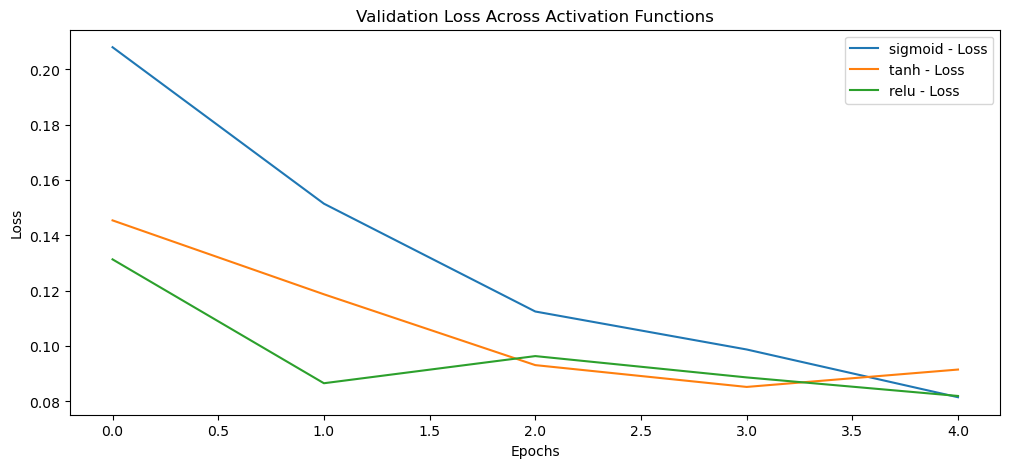

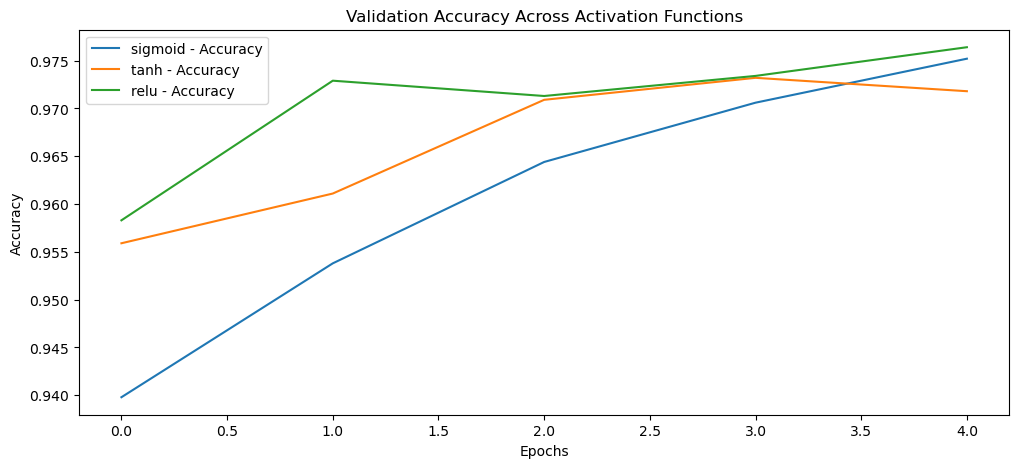

In [10]:
# Function to build the DNN model
def build_model(activation_function):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),  # Input layer
        tf.keras.layers.Dense(128, activation=activation_function),  # Hidden layer 1
        tf.keras.layers.Dense(64, activation=activation_function),   # Hidden layer 2
        tf.keras.layers.Dense(10, activation='softmax')  # Output layer
    ])
    return model

# Function to train the model and collect its history
def train_model(activation_function):
    model = build_model(activation_function)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)
    return history

# Train models with sigmoid, tanh, and ReLU
activations = ['sigmoid', 'tanh', 'relu']
histories = {}
for activation in activations:
    print(f"Training model with {activation} activation...")
    histories[activation] = train_model(activation)

# Plot Validation Accuracy and Loss
plt.figure(figsize=(12, 5))
for activation in activations:
    plt.plot(histories[activation].history['val_loss'], label=f'{activation} - Loss')
plt.title('Validation Loss Across Activation Functions')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for activation in activations:
    plt.plot(histories[activation].history['val_accuracy'], label=f'{activation} - Accuracy')
plt.title('Validation Accuracy Across Activation Functions')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Step 1.1.3: Demonstrating the Vanishing Gradient Problem

Computing gradients for sigmoid...
Computing gradients for tanh...
Computing gradients for relu...


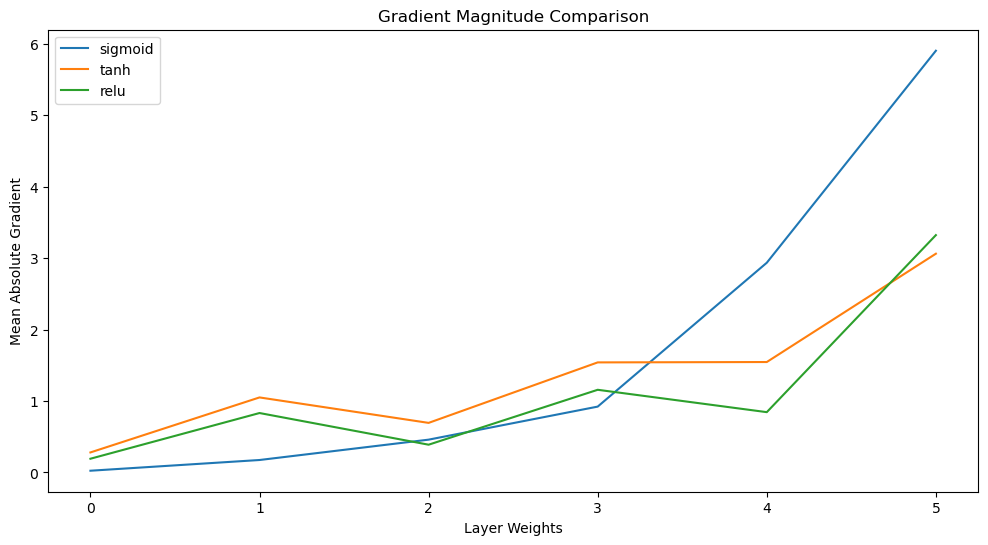

In [16]:
# Function to compute and visualize gradients
import numpy as np

def compute_gradients(activation_function, num_samples=100):
    model = build_model(activation_function)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Take a small batch of data
    x_batch = x_train[:num_samples]
    y_batch = y_train[:num_samples]
    
    with tf.GradientTape() as tape:
        predictions = model(x_batch, training=True)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_batch, predictions)
    
    gradients = tape.gradient(loss, model.trainable_weights)
    flat_gradients = [np.mean(np.abs(grad.numpy())) for grad in gradients if grad is not None]
    return flat_gradients

# Compute and plot gradients
gradient_data = {}
for activation in activations:
    print(f"Computing gradients for {activation}...")
    gradient_data[activation] = compute_gradients(activation)

# Plot gradient magnitudes
plt.figure(figsize=(12, 6))
for activation in activations:
    plt.plot(gradient_data[activation], label=f'{activation}')
plt.title('Gradient Magnitude Comparison')
plt.xlabel('Layer Weights')
plt.ylabel('Mean Absolute Gradient')
plt.legend()
plt.show()


1.2 Comparing ReLU Variants

Training model with ReLU...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8645 - loss: 0.4602 - val_accuracy: 0.9072 - val_loss: 0.3204
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9105 - loss: 0.3102 - val_accuracy: 0.9137 - val_loss: 0.2941
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9159 - loss: 0.2958 - val_accuracy: 0.9205 - val_loss: 0.2842
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9178 - loss: 0.2923 - val_accuracy: 0.9187 - val_loss: 0.2979
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9225 - loss: 0.2804 - val_accuracy: 0.9209 - val_loss: 0.2847
Training model with Leaky ReLU...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8771 - loss: 0.4184 - val_accuracy: 0.9528 - val_loss: 0.1584
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9600 - loss: 0.1368 - val_accuracy: 0.9659 - val_loss: 0.1081
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━

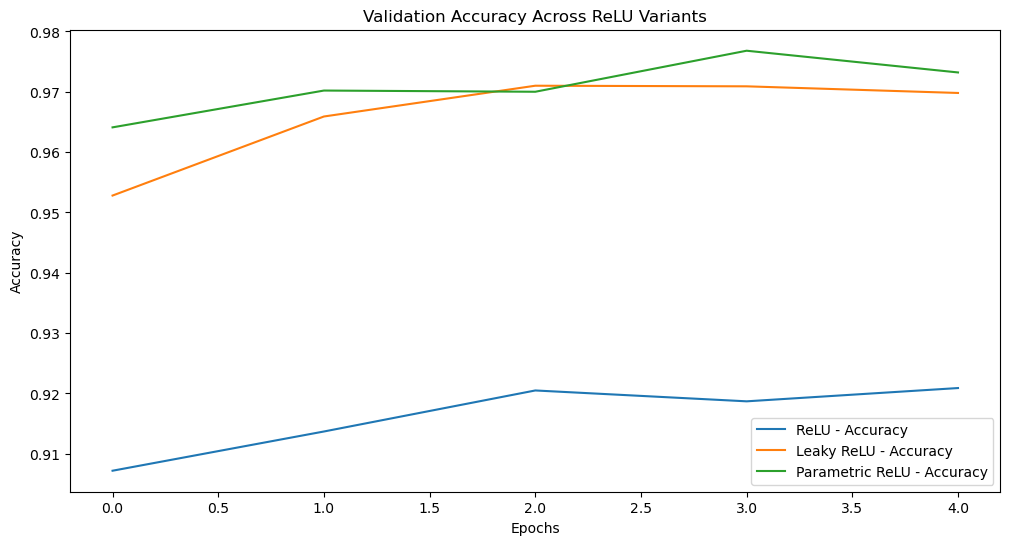

In [21]:
# Using ReLU Variants
def build_model_with_relu_variant(layer_type):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        layer_type(128),  # Hidden layer 1
        layer_type(64),   # Hidden layer 2
        tf.keras.layers.Dense(10, activation='softmax')  # Output layer
    ])
    return model

# Training ReLU Variants
relu_variants = {
    'ReLU': tf.keras.layers.Dense,
    'Leaky ReLU': lambda units: tf.keras.layers.Dense(units, activation=tf.keras.layers.LeakyReLU()),
    'Parametric ReLU': lambda units: tf.keras.layers.Dense(units, activation=tf.keras.layers.PReLU())
}
variant_histories = {}
for variant, layer in relu_variants.items():
    print(f"Training model with {variant}...")
    model = build_model_with_relu_variant(layer)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)
    variant_histories[variant] = history

# Plot Comparisons
plt.figure(figsize=(12, 6))
for variant in relu_variants.keys():
    plt.plot(variant_histories[variant].history['val_accuracy'], label=f'{variant} - Accuracy')
plt.title('Validation Accuracy Across ReLU Variants')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


2.1: Exploring Depth of Artificial Neural Networks (ANNs)

Training model with 1 hidden layers...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8759 - loss: 0.4364 - val_accuracy: 0.9597 - val_loss: 0.1413
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9652 - loss: 0.1208 - val_accuracy: 0.9688 - val_loss: 0.1032
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9769 - loss: 0.0779 - val_accuracy: 0.9734 - val_loss: 0.0827
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9833 - loss: 0.0575 - val_accuracy: 0.9717 - val_loss: 0.0919
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9856 - loss: 0.0464 - val_accuracy: 0.9768 - val_loss: 0.0771
Training model with 2 hidden layers...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8815 - loss: 0.4063 - val_accuracy: 0.9645 - val_loss: 0.1152
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9696 - loss: 0.1018 - val_accuracy: 0.9669 - val_loss: 0.1082
Epoch 3/5
1875/1875

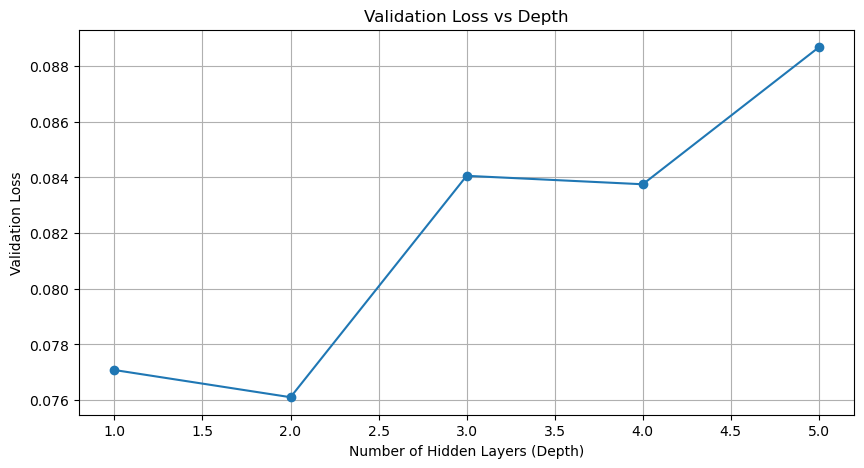

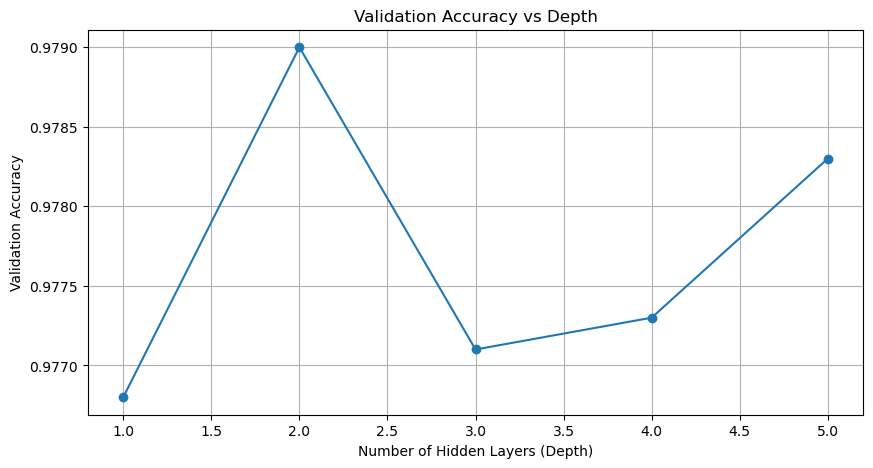

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize pixel values

# Updated function to build model with depth
def build_model_with_depth(depth):
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(28, 28)))  # Explicit Input layer
    model.add(tf.keras.layers.Flatten())  # Flatten input
    for _ in range(depth):
        model.add(tf.keras.layers.Dense(128, activation='relu'))  # Hidden layers
    model.add(tf.keras.layers.Dense(10, activation='softmax'))  # Output layer
    return model

# Function to train and evaluate
def train_and_evaluate(depth):
    model = build_model_with_depth(depth)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)
    return history

# Test models with varying depths
depths = [1, 2, 3, 4, 5]
results = {}
for depth in depths:
    print(f"Training model with {depth} hidden layers...")
    results[depth] = train_and_evaluate(depth)

# Plot Validation Loss vs Depth
val_loss = [results[depth].history['val_loss'][-1] for depth in depths]
plt.figure(figsize=(10, 5))
plt.plot(depths, val_loss, marker='o')
plt.title('Validation Loss vs Depth')
plt.xlabel('Number of Hidden Layers (Depth)')
plt.ylabel('Validation Loss')
plt.grid()
plt.show()

# Plot Validation Accuracy vs Depth
val_accuracy = [results[depth].history['val_accuracy'][-1] for depth in depths]
plt.figure(figsize=(10, 5))
plt.plot(depths, val_accuracy, marker='o')
plt.title('Validation Accuracy vs Depth')
plt.xlabel('Number of Hidden Layers (Depth)')
plt.ylabel('Validation Accuracy')
plt.grid()
plt.show()
